# thalamus: spindle2

In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\utils'))
sys.path.append(os.path.join(now_dir, r'models\spindle_demo'))

d:\mynew\demo_all


In [2]:

import pypet as pp 
import numpy as np 

# utils libs
import runModels as rm 
import defaultParameters as dp
params = dp.loadDefaultParams(0)
params["dt"] = 0.0001#0.0001
#params["Jet"] = 1.98
params

{'dt': 0.0001,
 'duration': 10,
 'model': 'spindle1',
 'tau_t': 0.044,
 'tau_r': 0.022,
 'f_t_max': 250,
 'f_r_max': 200,
 'f_t_th': 50,
 'f_r_th': 110,
 'gamma_t': 0.012,
 'gamma_r': 0.012,
 'At': 0.22,
 'Ar': 0.11,
 'tau_u_t': 0.22,
 'tau_u_r': 0.11,
 'RT_t': 100,
 'RT_r': 180,
 'RB_t': 250,
 'RB_r': 250,
 'VT_t': 26,
 'VT_r': 23,
 'VB_t': 15,
 'VB_r': 15,
 'gT_t': 6,
 'gT_r': 3,
 'gB_t': 0.9,
 'gB_r': 0.6,
 'Lt': 0.04,
 'Lr': 0.04,
 'Nt': 500.0,
 'Nr': 500.0,
 'Prr': 0.02,
 'Ptr': 0.01,
 'Prt': 0.04,
 'Jrr': -1.5,
 'Jtr': 13.68,
 'Jrt': -9.600000000000001,
 'V_t_init': 0,
 'V_r_init': 0,
 'Q_t_init': 0,
 'Q_r_init': 0,
 'u_t_init': 0,
 'u_r_init': 0}

In [3]:
# for test

#t, Q_t, Q_r, V_t, V_r, a_chunk, b_chunk, c_chunk, u_chunk, ar_chunk, br_chunk, cr_chunk, dr_chunk, ur_chunk = rm.runModels(manual_params=params)
#t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
t, Q_t, Q_r, V_t, V_r, u_chunk, ur_chunk = rm.runModels(manual_params=params)


d:\mynew\demo_all\models\spindle_demo\timeIntegration.py:126: RuntimeWarning: overflow encountered in exp
  return f_t_max / (1 + np.exp((u+f_t_th)/gamma_t))
d:\mynew\demo_all\models\spindle_demo\timeIntegration.py:128: RuntimeWarning: overflow encountered in exp
  return f_r_max / (1 + np.exp((u+f_r_th)/gamma_r))


In [4]:

#print(t)
#print(V_t[:100])
#print("a:", a_chunk[:100])
#print("b:", b_chunk[:100])
#print("c:", c_chunk[:100])
#print("u:", u_chunk[:100])
#print("Q_e:", Q_e[1000:2000])

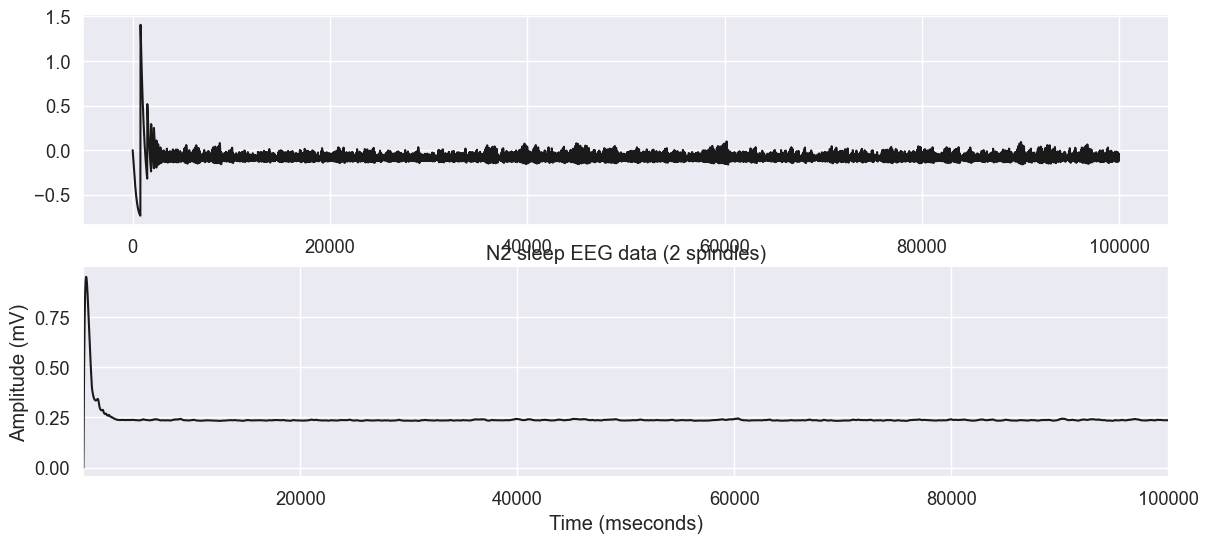

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(2, 1, figsize=(14, 6))
#plt.plot(t[:1000], V_t[:1000], lw=1.5, color='k')
plt.subplot(2,1,1)
plt.plot(t, V_t, lw=1.5, color='k')
#plt.plot(t[:10000], V_t[:10000], lw=1.5, color='k')
plt.subplot(2,1,2)
plt.plot(t, V_r, lw=1.5, color='k')
#plt.plot(t[:10000], V_r[:10000], lw=1.5, color='k')
plt.xlabel('Time (mseconds)')
plt.ylabel('Amplitude (mV)')
#
plt.xlim([t.min(), t.max()])
#plt.xlim([t[:10000].min(), t[:10000].max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

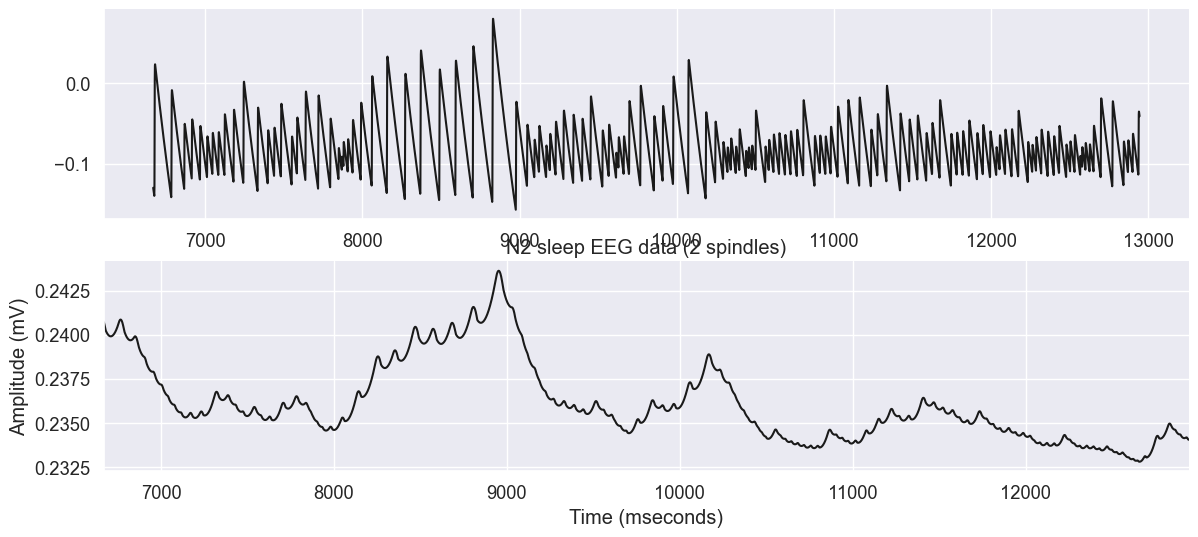

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(2, 1, figsize=(14, 6))
#plt.plot(t[:1000], V_t[:1000], lw=1.5, color='k')
plt.subplot(2,1,1)
#plt.plot(t, V_t, lw=1.5, color='k')
plt.plot(t[6668:12945], V_t[6668:12945], lw=1.5, color='k')
plt.subplot(2,1,2)
#plt.plot(t, V_r, lw=1.5, color='k')
plt.plot(t[6668:12945], V_r[6668:12945], lw=1.5, color='k')
plt.xlabel('Time (mseconds)')
plt.ylabel('Amplitude (mV)')
#
#plt.xlim([t.min(), t.max()])
plt.xlim([t[6668:12945].min(), t[6668:12945].max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [7]:

import yasa
import xarray as xr
duration = params["duration"] #/ 1000
sf = float(1.0 / (t[1] - t[0])) * (1/params["dt"])#10000
print(sf)
sp1 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(12,16), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.65, "rms":2})
print("TCR:", sp1.summary()) if sp1 else print("NO Fast spindle in TCR")
rate1 = len(sp1._events) / duration if sp1 else 0
print("Fast spindles:", rate1)

sp2 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(8,13), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.65, "rms":2})
print("TCR:",sp2.summary()) if sp2 else  print("NO Slow spindle in TCR")
#len(sp.summary()) # 9.7s, _events 9.5s
rate2 = len(sp2._events) / duration if sp2 else 0
print("Slow spindles:", rate2)

d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs
11-Mar-26 17:48:47 | ERROR | Wrong data amplitude for CHAN000 (trimmed STD = 0.029). Unit of data MUST be uV! Channel will be skipped.
11-Mar-26 17:48:47 | WARNING | All channels have bad amplitude. Returning None.
11-Mar-26 17:48:47 | ERROR | Wrong data amplitude for CHAN000 (trimmed STD = 0.029). Unit of data MUST be uV! Channel will be skipped.
11-Mar-26 17:48:47 | WARNING | All channels have bad amplitude. Returning None.


10000.0
NO Fast spindle in TCR
Fast spindles: 0
NO Slow spindle in TCR
Slow spindles: 0


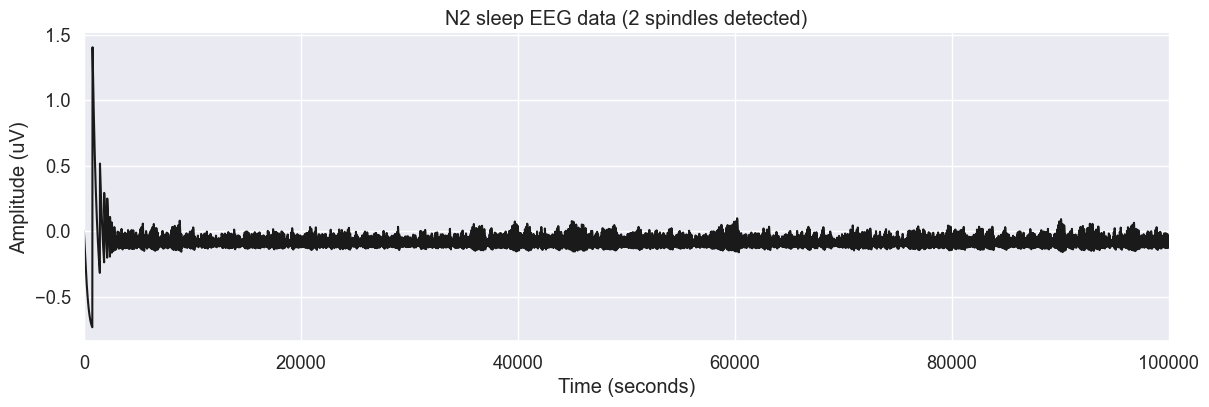

In [8]:
# Let's get a bool vector indicating for each sample
plt.figure(figsize=(14, 4))
#plt.plot(t[4000:6000], V_t[4000:6000], 'k')
plt.plot(t, V_t, 'k')
if sp1:
    mask1 = sp1.get_mask()
    spindles_highlight = V_t * mask1
    spindles_highlight[spindles_highlight == 0] = np.nan
    plt.plot(t, spindles_highlight, 'indianred')
    #plt.plot(t[4000:6000], spindles_highlight[4000:6000], 'indianred')


if sp2:
    mask2 = sp2.get_mask()
    spindles_highlight = V_t * mask2
    spindles_highlight[spindles_highlight == 0] = np.nan
    plt.plot(t, spindles_highlight, 'blue')
    #plt.plot(t[4000:6000], spindles_highlight[4000:6000], 'blue')


plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (uV)')
#plt.xlim([4000, 6000])
plt.xlim([0, t[-1]])
plt.title('N2 sleep EEG data (2 spindles detected)')
sns.despine()
# plt.savefig('detection.png', dpi=300, bbox_inches='tight')

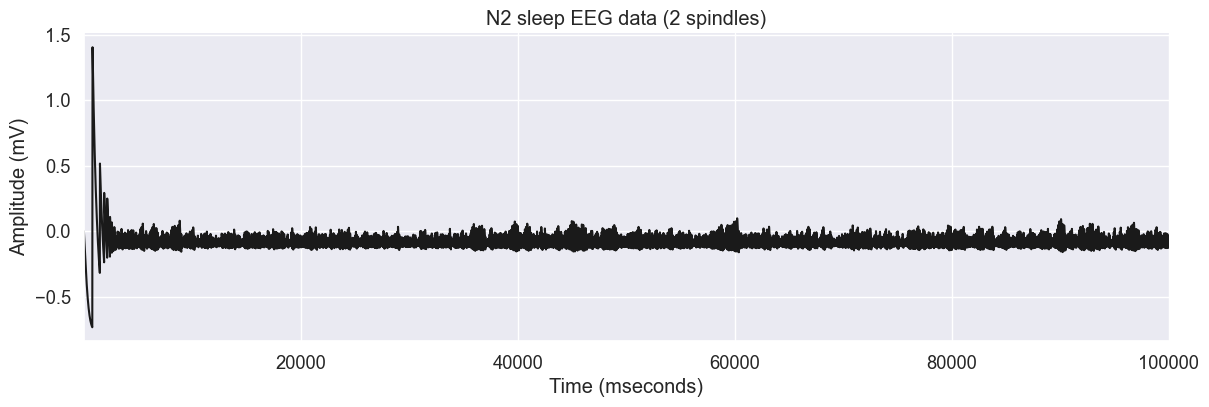

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t, V_t, lw=1.5, color='k')
#plt.plot(t, V_t, lw=1.5, color='k')
plt.xlabel('Time (mseconds)')
plt.ylabel('Amplitude (mV)')
#plt.xlim([t.min(), t.max()])
plt.xlim([t.min(), t.max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [10]:
print(V_r[:100])
#print("ar:", ar_chunk[:100])
#print("br:", br_chunk[:100])
#print("cr:", cr_chunk[:100])
#print("dr:", dr_chunk[:100])
#print("ur:", ur_chunk[:100])
print("Q_r:", Q_r[:100])

[0.         0.00871296 0.01738369 0.02601238 0.03459922 0.0431444
 0.05164811 0.06011054 0.06853188 0.07691231 0.08525201 0.09355117
 0.10180999 0.11002863 0.11820728 0.12634612 0.13444534 0.1425051
 0.15052561 0.15850702 0.16644952 0.17435328 0.18221849 0.19004531
 0.19783392 0.20558449 0.21329721 0.22097223 0.22860973 0.23620988
 0.24377285 0.25129881 0.25878793 0.26624038 0.27365631 0.28103591
 0.28837933 0.29568674 0.3029583  0.31019417 0.31739453 0.32455952
 0.33168932 0.33878407 0.34584395 0.35286911 0.3598597  0.36681589
 0.37373784 0.38062569 0.38747961 0.39429974 0.40108625 0.40783929
 0.414559   0.42124554 0.42789907 0.43451973 0.44110768 0.44766305
 0.45418601 0.4606767  0.46711632 0.47349572 0.47981532 0.48607549
 0.49227665 0.49841916 0.50450343 0.51052983 0.51649876 0.52241058
 0.52826568 0.53406444 0.53980722 0.5454944  0.55112636 0.55670345
 0.56222605 0.56769451 0.5731092  0.57847048 0.5837787  0.58903422
 0.59423739 0.59938857 0.6044881  0.60953632 0.61453359 0.619480

NameError: name 'V_e' is not defined

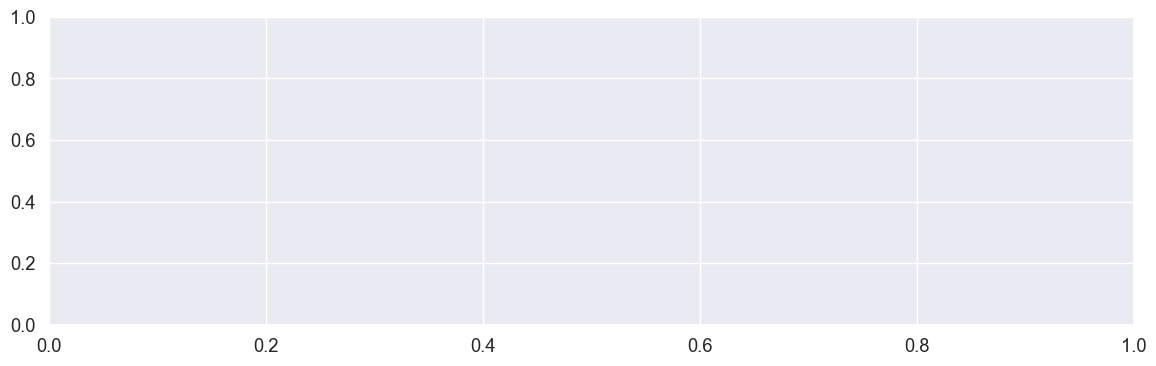

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t[:1000], V_e[:1000], lw=1.5, color='k')
plt.xlabel('Time (mseconds)')
plt.ylabel('Amplitude (mV)')
plt.xlim([t[:1000].min(), t[:1000].max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [ ]:

parametrization_demo = pp.cartesian_product({
    'g_h': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 16)],
    'g_LK': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 16)],
    'model': ['spindle1']
}) # {'a': [...], 'b': [...], 'model': [...]}


In [ ]:
# run simulations
trajectoryName = 'results'
HDF_DIR = '.\data\hdf'
trajectoryFileName = os.path.join(HDF_DIR, 'thalamus_demo.hdf') 

import multiprocessing
ncores = multiprocessing.cpu_count()
print(f"number of cores: {ncores}")

env = pp.Environment(trajectory=trajectoryName, filename=trajectoryFileName,
                     add_time=True,
                     multiproc=True,
                     ncores=ncores,
                     wrap_mode="QUEUE",
                     log_stdout=False,
                     log_config=None
                     )

In [ ]:
traj = env.v_trajectory

import pypet_parameter as pe
pe.add_parameters_all(traj, params)
traj.f_explore(parametrization_demo)
env.f_run(rm.runModels)
env.f_disable_logging()
print("Done.")

In [ ]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')
traj.f_load(filename=trajectoryFileName)
traj.v_auto_load = True 

In [ ]:
traj.f_get_parameters()


In [ ]:

traj.f_get_run_names()
dt = traj.f_get_parameters()['parameters.dt'].f_get()
print(dt)
a = traj.f_get_explored_parameters()['parameters.g_LK'].f_get_range()
print(a)
b = traj.f_get_explored_parameters()['parameters.g_h'].f_get_range()
print(b)



In [ ]:
traj.results.thalamus_results[0].V_t[0]
# traj.results.thalamus_results[0].V_t[0][:-1] # pay attention to the length(why longer than t?)
# traj.results.thalamus_results[0].f_to_dict()

In [ ]:
import pandas as pd
nResults = len(traj.f_get_run_names())
dt = traj.f_get_parameters()['parameters.dt'].f_get()
exploredParameters = traj.f_get_explored_parameters()

niceParKeys = [p.split('.')[-1] for p in exploredParameters.keys()]

dfResults = pd.DataFrame(columns=niceParKeys, dtype=object)

for nicep, p in zip(niceParKeys, exploredParameters.keys()):
    dfResults[nicep] = exploredParameters[p].f_get_range()

In [ ]:
from joblib import Parallel, delayed 
import multiprocessing 
from tqdm import *
num_cores = multiprocessing.cpu_count()

import yasa
duration = params["duration"] / 1000
sf = float(1.0 / (t[1] - t[0])) * 1000
sp = yasa.spindles_detect(V_t[0], sf)
#len(sp.summary()) # 9.7s, _events 9.5s

def cal_spindles(i):
    sp = yasa.spindles_detect(traj.results.thalamus_results[i].V_t[0], sf)
    rate = len(sp._events) / duration if sp else 0
    return rate

plot_results = Parallel(n_jobs=num_cores-4)(delayed(cal_spindles)(i) for i in tqdm(range(len(dfResults))))
print(plot_results)


In [ ]:
import matplotlib.pyplot as plt

g_LK = np.unique(dfResults['g_LK'])
g_h = np.unique(dfResults['g_h'])
plot_results_matrix = np.reshape(plot_results, (len(g_LK), len(g_h)))

plt.figure(figsize=(10,8), dpi=300)
plt.imshow(plot_results_matrix, origin='lower', aspect='auto', extent=[g_LK[0], g_LK[-1], g_h[0], g_h[-1]])

plt.xlabel("g_LK", fontsize=30)
plt.ylabel("g_h", fontsize=30)
plt.clim(0, 0.3)
cbar = plt.colorbar(label="spindles", extend='max')
plt.show()

In [ ]:
# spindle detection
import yasa
import logging
def scale_to_voltage(dataarray, feature_range=(-80, -20)):
    data_scale = (feature_range[1]- feature_range[0]) / (
        dataarray.max(dim="time") - dataarray.min(dim="time")
    )
    data_min = feature_range[0] - dataarray.min(dim="time") * data_scale
    return data_scale * dataarray + data_min
def spindles_detect_thalamus(tcr_ts, trn_ts=None, trn_median_thresh=5.0, **kwargs):
    assert tcr_ts.ndim == 1, "Only works on 1D timeseries"
    if tcr_ts.max() < 10.0 or tcr_ts.std() < 5.0:
        logging.warning("No spindles found: STD too low")
        return None
    if trn_ts is not None and np.nanmedian(trn_ts) < trn_median_thresh:
        logging.warning("No spindles found: TRN is not oscillating")
        return None
    sf = float(1.0 / (tcr_ts.time[1] - tcr_ts.time[0]))
    return yasa.spindles_detect(
        scale_to_voltage(tcr_ts).values, sf=sf, **kwargs
    )


In [ ]:
import yasa
import xarray as xr
# print(V_t)
print("V_t.shape:", V_t.shape)
data = np.diff(V_t[0]) * 1000  # pay attention to the unit(mV or uV)
# print(data)
print(data.shape)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

t1 = t[2000000:3000000] / 1000
print(t1.shape)
data1 = data[2000000:3000000]
print(data1.shape)


In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t1, data1, lw=1.5, color='k')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (uV)')
plt.xlim([t1.min(), t1.max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [ ]:

coords = t1
# 7000
tcr_ts = xr.DataArray(data1, coords=[coords], dims=['time'])

sf = 100000 # !!!  1000,000 data for 10 seconds
sp = yasa.spindles_detect(tcr_ts, sf, duration=(0.3, 2))
sp.summary()



In [ ]:

import xarray as xr
data = traj.results.thalamus_results[0].V_t[0][:-1] *1000 # pay attention to the unit(mV or uV)
coords = traj.results.thalamus_results[0].t
# 7000
tcr_ts = xr.DataArray(data, coords=[coords], dims=['time'])

sf = 200
sp = yasa.spindles_detect(tcr_ts, sf)
sp.summary()
